In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [3]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [5]:
from sklearn.model_selection import RandomizedSearchCV

In [6]:
df=pd.read_csv("data/stud.csv")

In [7]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
X=df.drop(columns=['math_score'],axis=1)

In [9]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [10]:
print("Categories in GENDER columns:",end=' ')
print(df['gender'].unique())
print("Categories in RACE/ETHNICITY columns:",end=' ')
print(df['race_ethnicity'].unique())
print("Categories in PARENTAL LEVEL OF EDUCATION columns:",end=' ')
print(df['parental_level_of_education'].unique())  
print("Categories in LUNCH columns:",end=' ')
print(df['lunch'].unique())
print("Categories in TEST PREPARATION COURSE columns:",end=' ')
print(df['test_preparation_course'].unique())

Categories in GENDER columns: ['female' 'male']
Categories in RACE/ETHNICITY columns: ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in PARENTAL LEVEL OF EDUCATION columns: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in LUNCH columns: ['standard' 'free/reduced']
Categories in TEST PREPARATION COURSE columns: ['none' 'completed']


In [11]:
y=df['math_score']

In [12]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [17]:
num_feature=X.select_dtypes(exclude='object').columns
cat_feature=X.select_dtypes(include='object').columns

numeric_transformation=StandardScaler()
categorical_transformation=OneHotEncoder()

preprocessor=ColumnTransformer(
    [('OneHotEncoder',categorical_transformation,cat_feature),('StandardScaler',numeric_transformation,num_feature)]
)

In [18]:
X=preprocessor.fit_transform(X)


In [19]:
X.shape

(1000, 19)

In [33]:
df.shape

(1000, 8)

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
X_train.shape

(800, 19)

In [24]:
X_test.shape

(200, 19)

In [54]:
def evaluate_model(true,predicted):
    mse=mean_squared_error(true,predicted)
    mae=mean_absolute_error(true,predicted)
    rmse=np.sqrt(mean_squared_error(true,predicted))
    r2=r2_score(true,predicted)
    return mae,mse,rmse,r2

In [57]:
models={
    "Linear Regression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "K-nearest neighbour":KNeighborsRegressor(),
    "Decision Tree":DecisionTreeRegressor(),
    "Random Forest":RandomForestRegressor(),
    "XG Boost":XGBRegressor(),
    "Cat boosting":CatBoostRegressor(verbose=False),
    "Adaboost":AdaBoostRegressor()
}

model_list=[]
r2_list=[]

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    model_train_mae,model_train_mse,model_train_rmse,model_train_r2=evaluate_model(y_train,y_train_pred)
    model_test_mae,model_test_mse,model_test_rmse,model_test_r2=evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model Performance of training set")
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))

    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model Performance of training set
Model performance for Training set
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804


Lasso
Model Performance of training set
Model performance for Training set
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253


Ridge
Model Performance of training set
Model performance for Training set
- Root Mean Squared Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3904
- Mean Absolute Error: 4.2111
- R2 Score: 0.8806


K-nearest neighbour
Model Performance of training set
Model p

In [59]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name','R2_score']).sort_values(by=['R2_score'],ascending=False)

,Model Name,R2_score
2,Ridge,0.880593
0,Linear Regression,0.880433
5,Random Forest,0.852000
7,Cat boosting,0.851632
8,Adaboost,0.844355
6,XG Boost,0.827797
1,Lasso,0.825320
3,K-nearest neighbour,0.783813
4,Decision Tree,0.747697


In [62]:
linear_model=LinearRegression()
linear_model=linear_model.fit(X_train,y_train)
y_pred=linear_model.predict(X_test)
score=r2_score(y_test,y_pred)*100

print("Accuracy of the model is %.2f" %score)

Accuracy of the model is 88.04


Text(0, 0.5, 'Predicted')

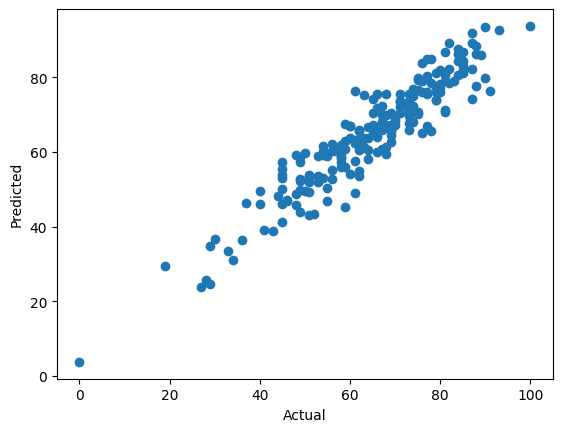

In [63]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

<Axes: xlabel='math_score'>

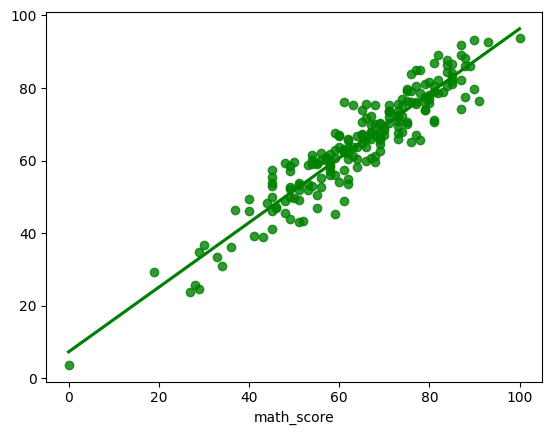

In [65]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='green')

In [68]:
pred_df=pd.DataFrame(
    {
        "Actual value":y_test,
        "Predicted value":y_pred,
        "Difference":y_test-y_pred
    }
)

In [70]:
pred_df

,Actual value,Predicted value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
